During data cleaning it became clear that a significant subset of application table is dedicated for defining the neighbourhood of the house. The data also seemed to be susceptible to collinearity and the need for dimensionality reduction and unsupervised learning was recognized, consequently this notebook will:
* Perform EDA on the house parameter variables.
* Attempt dimensionality reduction and unsupervised learning techniques
* Evaluate effect of these on competition performance. 

In [1]:
import pandas as pd
import numpy as np
import importlib
import itertools
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
import hdbscan

from helpers import preprocessing, submissions, one_off_plots, cluster_helper
from helpers.utils import plotting_helper, stats_helper, vif_helper,unsupervised_helper, plotting_helper

# Preparation

In [2]:
app_train = preprocessing.load_pkl_to_preprocessor("application_train")
app_train.convert_all("category")
print(app_train.column_structure)
nb4_pkl = {}

Loading tables: ['application_train.csv']
Loaded application_train with shape (307511, 122)
{'core_identification': ['SK_ID_CURR', 'TARGET'], 'loan_basics': ['NAME_CONTRACT_TYPE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'], 'financial_info': ['AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'], 'assets': ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'OWN_CAR_AGE'], 'time_features': ['DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'HOUR_APPR_PROCESS_START'], 'contact_flags': ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'], 'demographics': ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH'], 'external_sources': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'], 'location_features': ['REGION_POPULATION_RELATIVE', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CIT

We then identify the housing data subset of interest.

In [3]:
housing_structure = {
    key: app_train.column_structure[key]
    for key in ["building_properties", "building_avg", "building_mode", "building_medi"]
}

print("housing_structure:", housing_structure)
housing_columns = list(itertools.chain(*housing_structure.values()))
print("housing_columns:", housing_columns)

housing_structure: {'building_properties': ['EMERGENCYSTATE_MODE', 'FONDKAPREMONT_MODE', 'WALLSMATERIAL_MODE', 'HOUSETYPE_MODE'], 'building_avg': ['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'], 'building_mode': ['APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'TOTALAREA_MODE'], 'building_medi': ['APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI'

This data is prepared for simple use.

In [4]:
house_df = app_train.data[housing_columns + ["TARGET"]].select_dtypes(include=[np.number])
display(house_df)

,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,...,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TARGET
0,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,...,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,1
1,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,...,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,0.1034,0.6042,0.2708,0.0594,...,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,0
307507,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,0.1034,0.0833,0.1250,0.0579,...,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,0
307508,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,0.2069,0.1667,0.2083,NaN,...,0.00,0.2069,0.1667,0.2083,NaN,0.0855,0.9445,0.0000,0.0000,0
307509,0.0124,NaN,0.9771,NaN,NaN,NaN,0.0690,0.0417,NaN,NaN,...,NaN,0.0690,0.0417,NaN,NaN,NaN,0.0062,NaN,NaN,1


# PCA of current features

In [5]:
plotting_helper.set_plot_style()

unsupervised_helper.plotly_3d_pca(house_df, hue_col = "TARGET")

Plotting 3D PCA with discarded NANs


* Three first PCA components are unable to capture any meaningful patterns of target distribution, except that it identified targets appear to correlate with general frequency distribution.

# Feature Reduction

## Correlation and collinearity

Text(0.5, 1.0, 'Pearson correlation for house neighbourhood parameters')

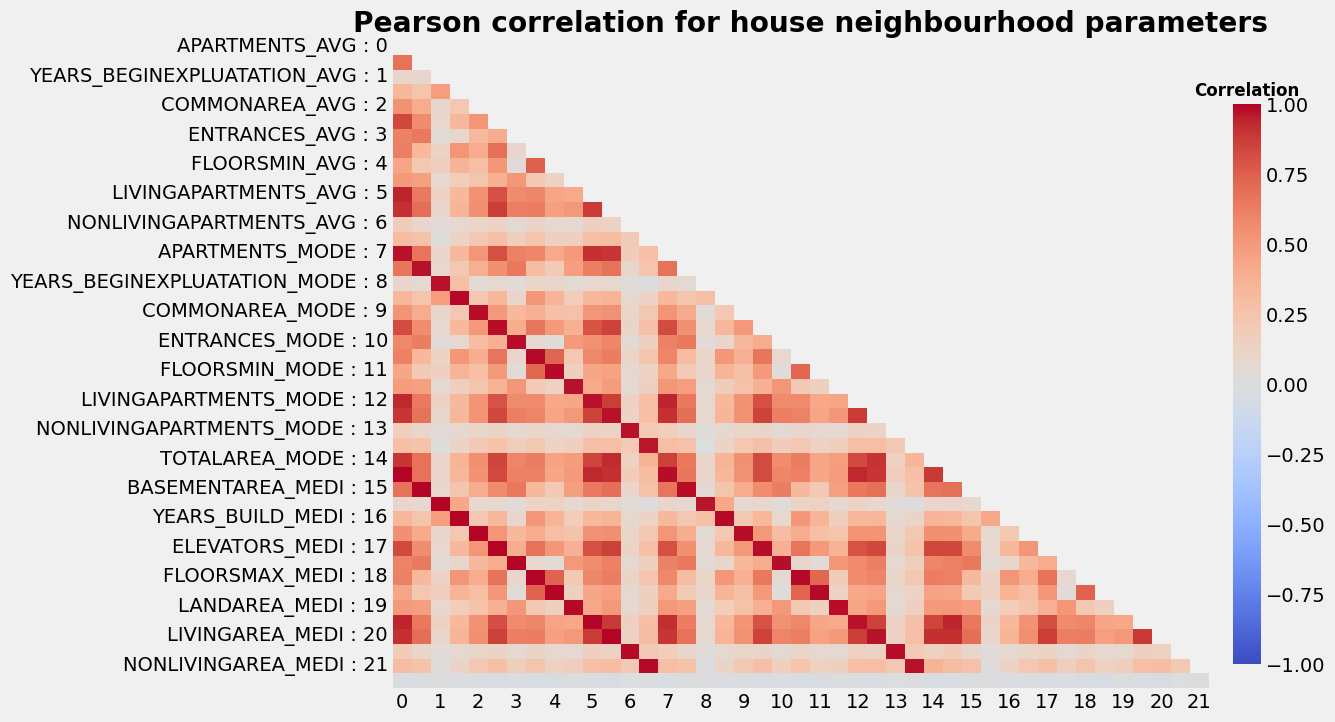

In [6]:
plotting_helper.plot_corr_triangle(house_df, "pearson", "TARGET", (12, 8))
plt.title("Pearson correlation for house neighbourhood parameters")

* There is significant covariance between numerous features.
* Average (mean), Median, Mode twin statistics are very strongly correlated, which would cause linear models to fail.
    * The broad trends (ignoring hard values) seem to be mostly repeated.
* There is no association between these and the target variable.
* The broad trends, when 

Our choice of tree ensemble model is more resistant to multicollinearity than linear methods, which should decrease impact of this issue.


## Comparison of building avg, median, and mode distributions.

### Correlation

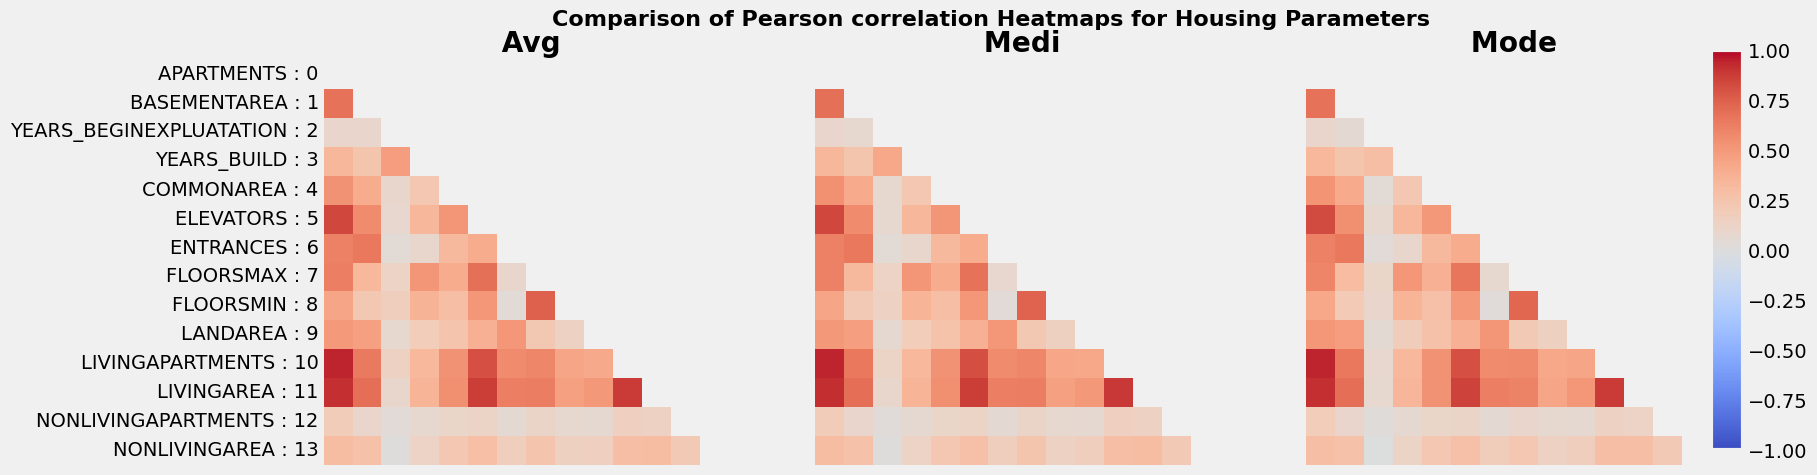

In [7]:
metric_suffixes = ["_AVG", "_MEDI", "_MODE"]
titles = ["Average (Mean)", "Median", "Mode"]

corr_tables = one_off_plots.plot_metric_comparison(
    house_df.drop(columns="TOTALAREA_MODE"),
    metric_suffixes,
    "Comparison of Pearson correlation Heatmaps for Housing Parameters",
    titles,
)

* Feature correlation distributions are near identical.
* These values should make the features highly interchangeable for analysis purposes.

This suggests that, quite likely, Avg, Medi, and Mode are  of identical ranking, but scaled.

In [8]:
for key, corr_table in corr_tables.items():
    mask = np.triu(np.ones_like(corr_table, dtype=bool))
    masked_corr = corr_table.where(~mask, 0)
    print(f"Sum of upper triangle values for {key}: {masked_corr.values.sum()}")
    plt.show()

Sum of upper triangle values for _AVG: 31.948200113778064
Sum of upper triangle values for _MEDI: 31.75538710801566
Sum of upper triangle values for _MODE: 31.012902671205982


* The overall plot correlation values are close enough to show extremely similar association patterns.
* MODE possesses most orthogonal values.

This indicates very similar relationships, however ranking my reveal differences in trend.

### Kendall's tau, pairwise ordering
A more precise ranking metric kendall's tau was used to evaluate whether the ranking relationship is identical. It was chosen over spearman correlation due to robustness to outliers and simpler interpretation. Both techniques are preferable for non-parametric data.

kendall's tau measures the correspondence between two rankings. It ranges in values from -1 (strong disagreement) to +1 (strong agreement).

In [9]:
stats_helper.compare_ordering_metrics(house_df, metric_suffixes, test=stats.kendalltau)

,_AVG vs _MEDI,_AVG vs _MODE,_MEDI vs _MODE,Bonferroni sum p_value
Feature,,,,
APARTMENTS,0.982906,0.925403,0.938032,0.0
BASEMENTAREA,0.981985,0.919794,0.929244,0.0
YEARS_BEGINEXPLUATATION,0.991102,0.963821,0.968883,0.0
YEARS_BUILD,0.993442,0.969653,0.973709,0.0
COMMONAREA,0.987001,0.935826,0.944662,0.0
ELEVATORS,0.983990,0.947926,0.963020,0.0
ENTRANCES,0.983204,0.927754,0.944184,0.0
FLOORSMAX,0.987701,0.963604,0.975208,0.0
FLOORSMIN,0.989972,0.966797,0.976396,0.0


* Extremely strong association (>0.9) was observed between all variables.
    * AVG vs MEDIUM ordering is near identical - mean column corr  0.98
    * AVG appears to be slightly less representative of MODE (mean column corr ~0.94), for which MEDIAN is more representative (mean column corr ~0.95).

Consequently, given the nature of ensemble tree classifiers (ignored shape of variables), we can choose a single metric for the model. In this context, **Median best represents two other metrics and is easy to interpret**. 

In [10]:
discard_columns = [
    col
    for col in house_df.columns
    if (
        col.endswith(("_AVG", "_MODE"))
        and col.replace("_MODE", "_AVG") in house_df.columns
    )
]
discard_columns

['APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMAX_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE']

In [11]:
vif_data = house_df.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 81552 entries, 0 to 307507
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   APARTMENTS_AVG                81552 non-null  float64
 1   BASEMENTAREA_AVG              81552 non-null  float64
 2   YEARS_BEGINEXPLUATATION_AVG   81552 non-null  float64
 3   YEARS_BUILD_AVG               81552 non-null  float64
 4   COMMONAREA_AVG                81552 non-null  float64
 5   ELEVATORS_AVG                 81552 non-null  float64
 6   ENTRANCES_AVG                 81552 non-null  float64
 7   FLOORSMAX_AVG                 81552 non-null  float64
 8   FLOORSMIN_AVG                 81552 non-null  float64
 9   LANDAREA_AVG                  81552 non-null  float64
 10  LIVINGAPARTMENTS_AVG          81552 non-null  float64
 11  LIVINGAREA_AVG                81552 non-null  float64
 12  NONLIVINGAPARTMENTS_AVG       81552 non-null  float64
 13  NONLI

### VIF comparison of feature reduction.

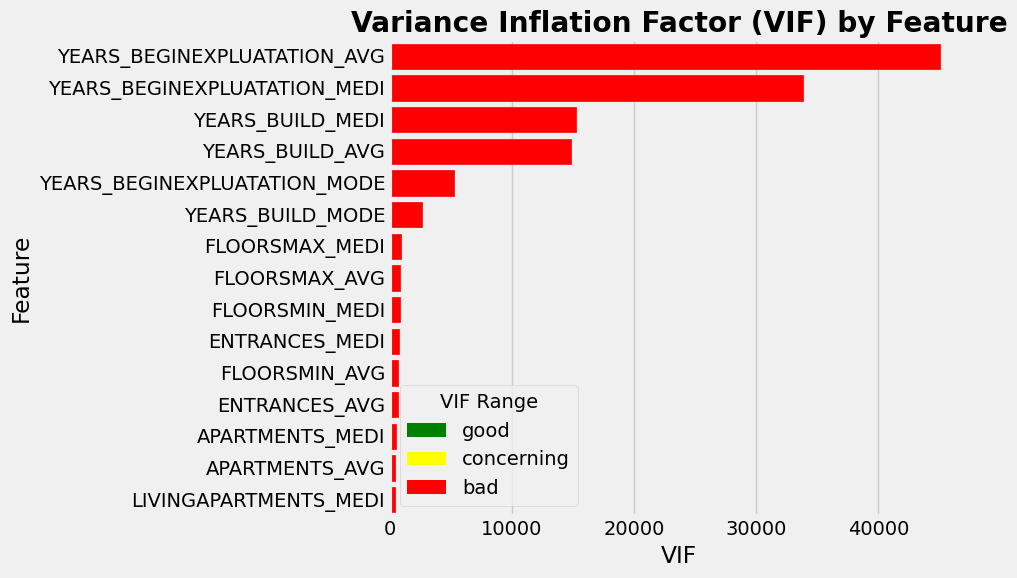

In [12]:
vif_helper.plot_vif(house_df.drop(columns=["TARGET"]), top_n=15);

**VIF is unacceptable. Feature selection is required.**

['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE']


,Feature,VIF
0,YEARS_BUILD_MEDI,77.815061
1,YEARS_BEGINEXPLUATATION_MEDI,66.872365
2,APARTMENTS_MEDI,34.342917
3,LIVINGAREA_MEDI,25.914296
4,LIVINGAPARTMENTS_MEDI,22.177596
5,FLOORSMAX_MEDI,16.387341
6,TOTALAREA_MODE,14.352875
7,ENTRANCES_MEDI,10.001353
8,ELEVATORS_MEDI,8.006281
9,FLOORSMIN_MEDI,7.230622


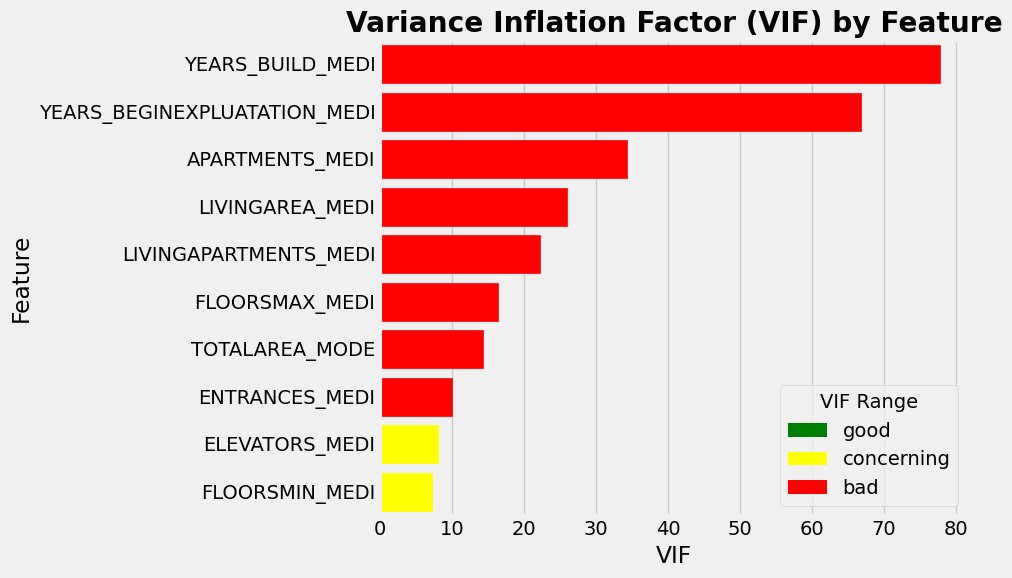

In [13]:
print(discard_columns)
vif_helper.plot_vif(house_df.drop(columns=discard_columns+['TARGET']))

* Although VIF is still too high, it was significantly reduced.

## Selected feature evaluation

In [14]:
app_train = preprocessing.load_pkl_to_preprocessor("application_train")
app_train.convert_all("category")

X_train, y_train, id_train = app_train.get_X_y_id()


app_test = preprocessing.load_pkl_to_preprocessor("application_test")
app_test.convert_all("category")

X_test, y_test, id_test = app_test.get_X_y_id()

Loading tables: ['application_train.csv']
Using cached application_train with shape (307511, 122)
X shape: (307511, 120), y shape: (307511,), id shape: (307511,)
Loading tables: ['application_test.csv']
Loaded application_test with shape (48744, 121)
X shape: (48744, 120), y shape: None, id shape: (48744,)


We first investigate whether housing columns are at all important to models performance.

In [15]:
submissions.cv_lgbm(X_train.drop(columns=housing_columns, errors="ignore"), y_train)

,average_precision,roc_auc,f1_macro
mean,0.2405,0.7565,0.5422
std,0.0055,0.0034,0.0017


Crossvalidation results appear to be almost identical to original ones:
| Average Precision | ROC AUC | F1 Macro |
|-------------------|---------|----------|
| 0.2408            | 0.7568  | 0.5428   |

Consequently, we can consider original housing features almost negligible, thus requiring feature engineering.

# Clustering
Previous analysis has proven that majority of variance can be captured by using just MODE measure. Consequently, EDA, and attached feature engineering on housing information will be performed by it.

Our features of interest thus are:

In [16]:
house_data = app_train.data[housing_columns + ["TARGET"]].select_dtypes(include=[np.number])
house_data = house_data[[col for col in house_data.columns if col.endswith(("_MODE"))]]
num_house_features = house_data.columns.tolist()

* **Note** initial distributions are not illuminating and thus are not repeated. They can be found in nb1

## Unsupervised learning
To better interpret features, attempts in grouping of meaningful categories will be made.

HDBSCAN is a natural choice, given its high, abstract shape clustering performance, and unknown number of groups of interest.

HDBSCAN library implementation will be used (over sklearn) due to handy inbuilt features (mainly condensed tree plot). It also does not require prior scaling, which simplifies our pipeline.

In [17]:
combined_df = pd.concat([
    X_train[num_house_features[:-1]].assign(ID=id_train),
    X_test[num_house_features[:-1]].assign(ID=id_test),
], ignore_index=True)

combined_df.shape

(356255, 15)

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\GITHUB\Turing submissions\psauci-DS.v2.5.3.4.1\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



[-1  0  1  2  3  4]


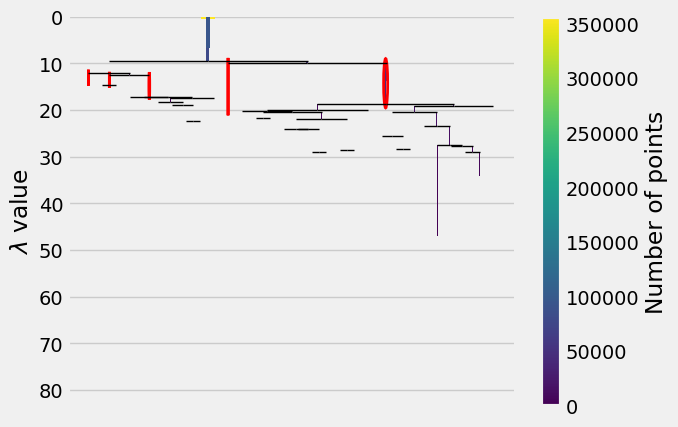

In [18]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100)


labels= clusterer.fit_predict(combined_df.drop(columns="ID", inplace=False))

labels_train = labels[combined_df.ID.isin(id_train)]
labels_test = labels[combined_df.ID.isin(id_test)]


clusterer.condensed_tree_.plot(select_clusters=True)

print(np.unique(labels_train))

The algorithm has successfully identified 5 unique groups and noise.

In [19]:
X_train["Cluster_Label"] = pd.Categorical(labels_train)
X_test["Cluster_Label"] = pd.Categorical(labels_test)
submissions.cv_lgbm(X_train.drop(columns=housing_columns, errors="ignore"), y_train)

,average_precision,roc_auc,f1_macro
mean,0.2398,0.7563,0.5420
std,0.0054,0.0036,0.0018


However, inclusion of metric does not capture performance loss from feature removal.
| Average Precision | ROC AUC | F1 Macro |
|-------------------|---------|----------|
| 0.2408            | 0.7568  | 0.5428   |


## Statistical tests

Such clustering fails to meaningfully improve model and can be considered non-informative performance.

#### Difference in groups - Kruskal–Wallis test

Metrics of assigned groups are then compared using Kruskal–Wallis test.


In [20]:
kruskal_results_df = stats_helper.kruskal_wallis_test(X_train.assign(TARGET=app_train.data.TARGET), num_house_features, "Cluster_Label")
display(kruskal_results_df)

,statistic,p_value,raw_p_value
APARTMENTS_MODE,12267.747860,0.0,0.0
BASEMENTAREA_MODE,6694.044854,0.0,0.0
YEARS_BEGINEXPLUATATION_MODE,10881.977391,0.0,0.0
YEARS_BUILD_MODE,14829.670248,0.0,0.0
COMMONAREA_MODE,12490.453496,0.0,0.0
ELEVATORS_MODE,42295.867269,0.0,0.0
ENTRANCES_MODE,3368.909570,0.0,0.0
FLOORSMAX_MODE,29842.087420,0.0,0.0
FLOORSMIN_MODE,27203.134126,0.0,0.0
LANDAREA_MODE,2491.943398,0.0,0.0


It appears that at least some of the groups are statistically different for identifies metric, we thus attempt to identify whether any of these can separate TARGET variable.

#### Inter cluster TARGET comparison

Difference in median value for each feature by target is then investigated by Wilcoxon signed rank test. Bonferroni correction is applied.

In [21]:
app_train.data.TARGET.info()

<class 'pandas.core.series.Series'>
RangeIndex: 307511 entries, 0 to 307510
Series name: TARGET
Non-Null Count   Dtype
--------------   -----
307511 non-null  int64
dtypes: int64(1)
memory usage: 2.3 MB


Corrected p-values for Wilcoxon test within clusters:


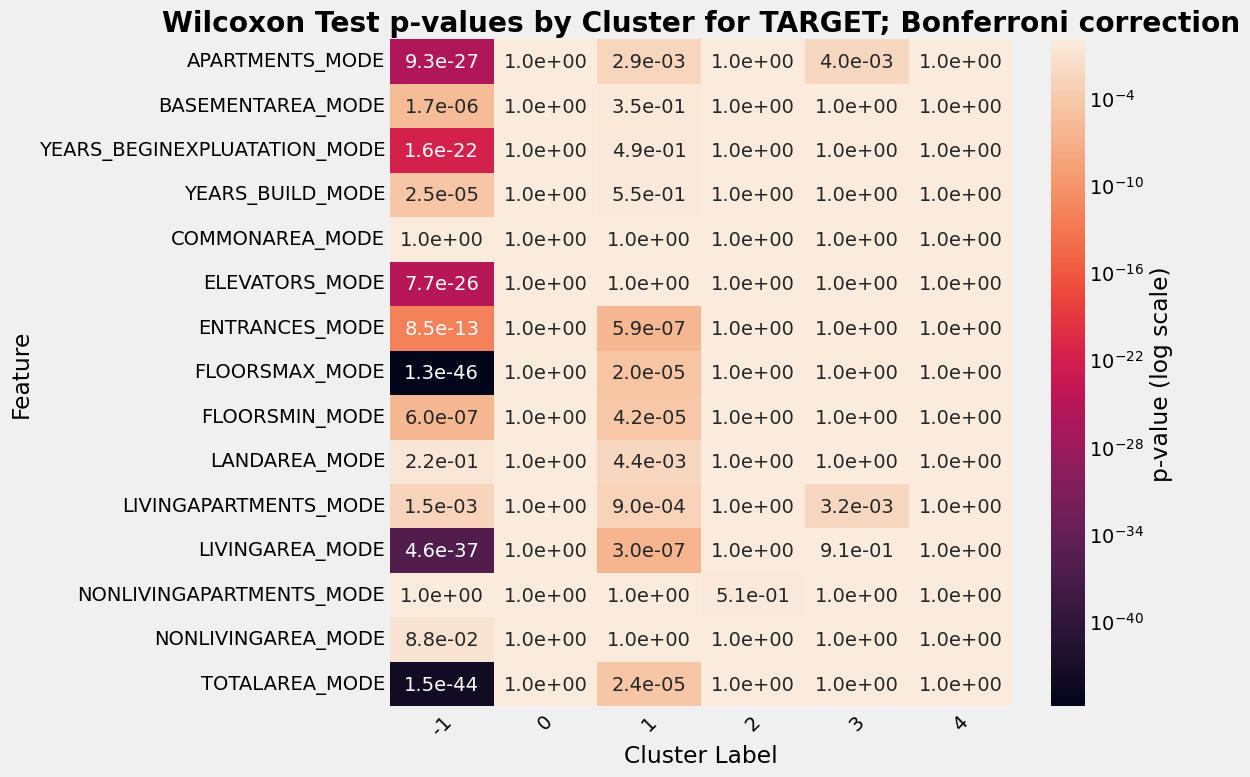

In [22]:
wilc_results = stats_helper.wilcoxon_test_within_cluster(
    X_train.assign(TARGET=app_train.data.TARGET), num_house_features, "Cluster_Label", "TARGET"
)


stats_helper.heatmap_wilcoxon_cluster_results(
    wilc_results, "Wilcoxon Test p-values by Cluster for TARGET; Bonferroni correction"
)

We have identified that the clusters -1 (noise) and 1 can have statistically different medians for certain features.

#### Encoded clusters

In [23]:
X_train = app_train.get_X_y_id()[0].copy()

X_train_neigh = cluster_helper.neighbourhood_feature_selection(
    X_train, labels_train, housing_columns, wilc_results
)

X shape: (307511, 120), y shape: (307511,), id shape: (307511,)
Selected 94 features after neighbourhood feature selection.


In [24]:
submissions.cv_lgbm(X_train_neigh, y_train)

,average_precision,roc_auc,f1_macro
mean,0.2404,0.7568,0.5426
std,0.0055,0.0036,0.0016


The model appears to have very slightly improved over base model, however, we need to confirm for this not being an effect of data leakage from cross validation.

| Average Precision | ROC AUC | F1 Macro |
|-------------------|---------|----------|
| 0.2408            | 0.7568  | 0.5428   |

Consequently, we attempt a submission:

In [25]:
from lightgbm import LGBMClassifier


X_test = app_test.get_X_y_id()[0].copy()
X_test_neigh = cluster_helper.neighbourhood_feature_selection(
    X_test, labels_test, housing_columns, wilc_results
)
submissions.prepare_submission(
    LGBMClassifier(is_unbalance=True, random_state=3, verbose=-1).fit(X_train_neigh, y_train),
    X_test_neigh,
    id_test,
    "clustered neighbourhood.csv",
)

X shape: (48744, 120), y shape: None, id shape: (48744,)
Selected 94 features after neighbourhood feature selection.
Submission created: submissions\sub_2025-08-08_15-29_clustered neighbourhood.csv.csv


'submissions\\sub_2025-08-08_15-29_clustered neighbourhood.csv.csv'

The model has:
* Achieved a slightly higher public score: 0.74272 vs 0.74262
* Achieved a lower private score: 0.74217 vs 0.7296

**Consequently, the approach is deemed unsuccessful and will not be further pursued.**

# EDA (Neighborhood descriptions)
For purpose of this investigation, we look whether the identified neighbourhood clusters and how they split the TARGET variable.
"noise" points are excluded for visualisation purposes. 

In [26]:
house_df['Cluster_Label'] = pd.Categorical(labels_train)
house_df = house_df.loc[house_df['Cluster_Label'] != -1, :]
house_df['Cluster_Label'] = house_df['Cluster_Label'].astype(int).astype('category')


interest_columns = (set(housing_columns) - set(discard_columns))
interest_columns

{'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'EMERGENCYSTATE_MODE',
 'ENTRANCES_MEDI',
 'FLOORSMAX_MEDI',
 'FLOORSMIN_MEDI',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'TOTALAREA_MODE',
 'WALLSMATERIAL_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BUILD_MEDI'}

# Area

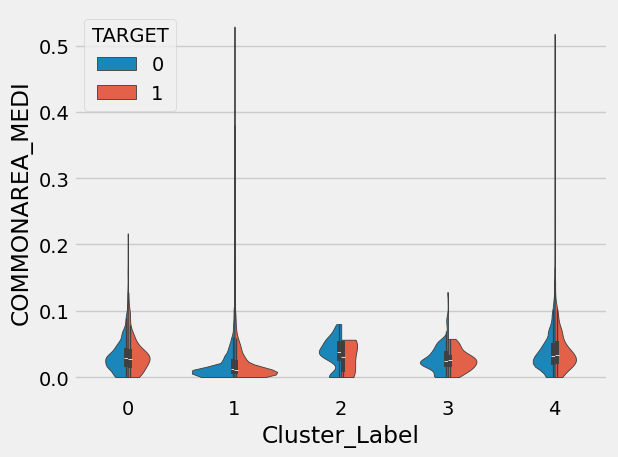

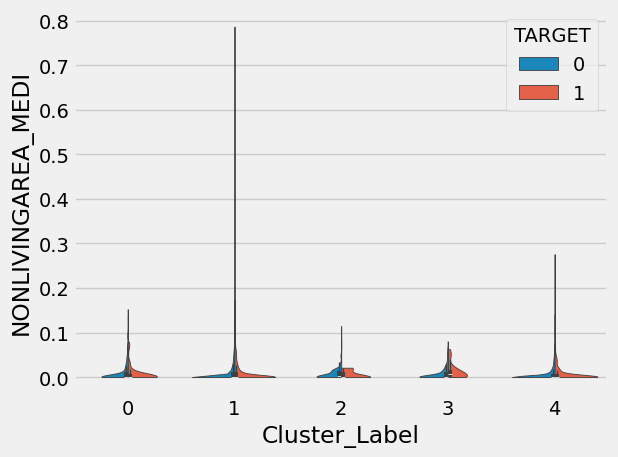

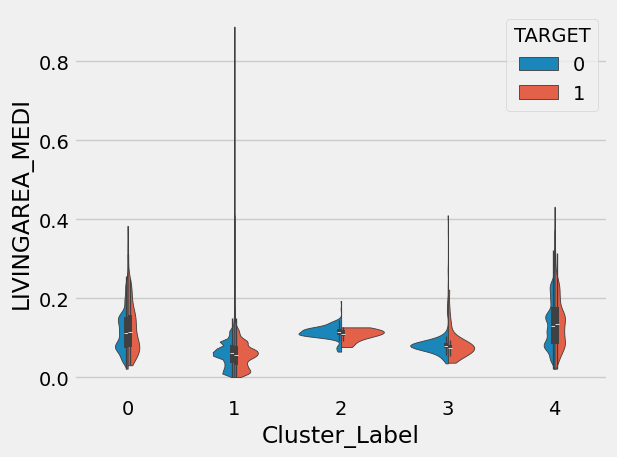

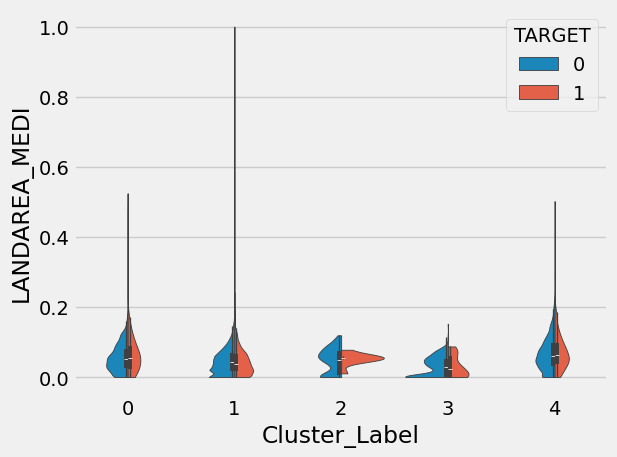

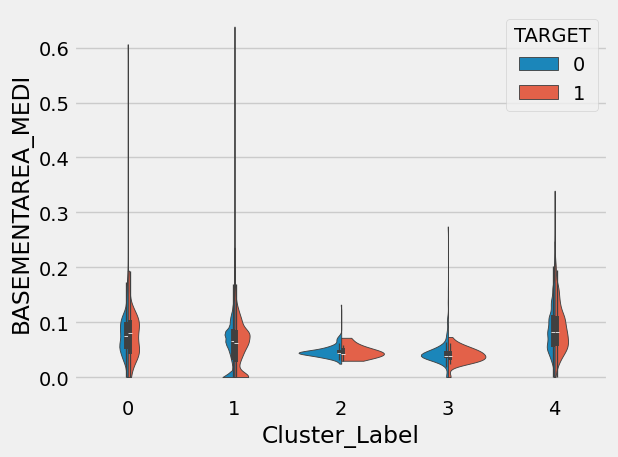

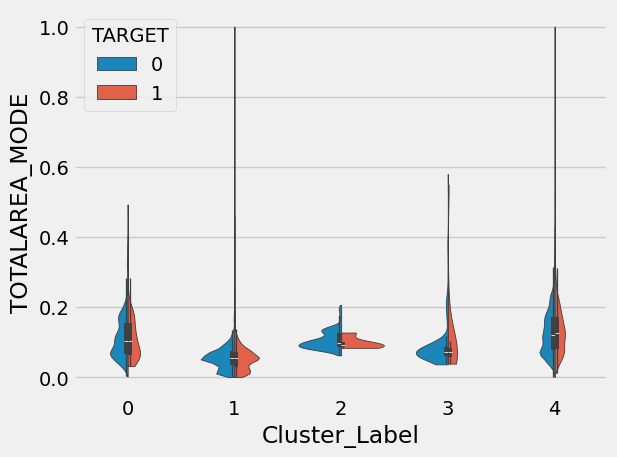

In [27]:
area_cols = [col for col in interest_columns if "AREA" in col]

for i, col in enumerate(area_cols):

    sns.violinplot(
        x='Cluster_Label',
        y=col,
        data=house_df,
        split =True,
        hue = 'TARGET',
        cut=0
    )
    plt.tight_layout()
    plt.show()


plt.show()

* Each cluster has distinct distribution shape, however it is unlikely that actionable insight will be derived.

# Conclusions
* Mean, Median, and Mode application features are near identical in ordering. Their choice has minimal effect on model performance.
* Inclusion of house location and neighborhood features has marginal effect on model performance.
* Clustering (HDBSCAN) and related feature engineering was deemed unsuccessful in objectively increasing model performance.